# Generative modelling case study

**Student Name:** Dekshina Udayan

**Student ID:** 24068646

This notebook contains the implementation of all tasks required for the GAN assignment.

The assignment consists of:

- **Part 1:** Building and Understanding GANs from Scratch
- **Part 2.1:** Medical Image Generation using OCTMNIST
- **Part 2.2:** Synthetic Network Traffic Generation using CICIDS2017
- **Part 2.3:** Creative AI using the QuickDraw Birthday Cake Dataset

All experiments are implemented using **PyTorch**, with appropriate visualisations and evaluation metrics.

# Part 1 – Building and Understanding GANs from Scratch

## Objective

The objective of this section is to reinforce the fundamental concepts of Generative Adversarial Networks (GANs) by implementing and training GAN models from scratch using PyTorch on synthetic two-dimensional datasets.

This section consists of three tasks:

- Reproducing the sine-wave GAN presented in the tutorial.
- Modelling a new two-dimensional distribution using a Mixture of Gaussians.
- Modifying the GAN architecture and comparing the generated samples with the original implementation.

These experiments provide an understanding of adversarial learning before applying GANs to real-world datasets in Part 2.

## Part 1.1 – Reproducing the Sine-Wave GAN

### Objective

The aim of this experiment is to reproduce the sine-wave GAN presented in the tutorial using PyTorch. This experiment demonstrates the basic adversarial learning process, where the Generator learns to produce synthetic samples that closely follow the original sine-wave distribution while the Discriminator learns to distinguish between real and generated samples.

## 1.1 Import Required Libraries

The following libraries are used throughout this notebook.

- **NumPy** for numerical operations.
- **Matplotlib** for visualisation.
- **PyTorch** for implementing the Generator and Discriminator networks.
- Random seeds are fixed to ensure that the experiments are reproducible.

In [6]:
# ============================================================
# Import required libraries
# ============================================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## 1.2 Generate the Sine-Wave Dataset

The tutorial introduces GANs using a simple two-dimensional sine-wave dataset.

Each training sample consists of an input coordinate \(x\) and its corresponding value

\[
y=\sin(x)
\]

The Generator will learn to approximate this distribution during training.

In [7]:
# ============================================================
# Generate a synthetic sine-wave dataset
# ============================================================

def create_sine_dataset(n_samples=1024):
    """
    Generate a two-dimensional sine-wave dataset.

    Parameters
    ----------
    n_samples : int
        Number of samples to generate.

    Returns
    -------
    Tensor
        Tensor containing (x,y) coordinates.
    """

    data = torch.zeros((n_samples, 2))

    data[:, 0] = 2 * math.pi * torch.rand(n_samples)
    data[:, 1] = torch.sin(data[:, 0])

    return data


train_data = create_sine_dataset()

## 1.3 Visualise the Dataset

Before training begins, the original training samples are visualised.

This figure represents the true data distribution that the Generator attempts to learn.

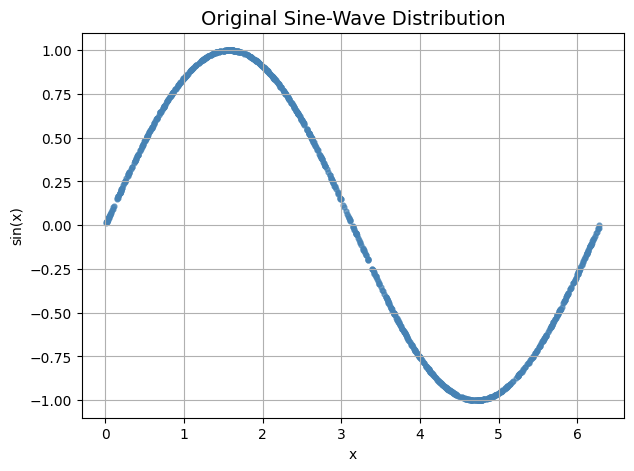

In [8]:
# ============================================================
# Visualise the original dataset
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(
    train_data[:,0],
    train_data[:,1],
    s=12,
    alpha=0.7,
    color="steelblue"
)

plt.title("Original Sine-Wave Distribution", fontsize=14)

plt.xlabel("x")

plt.ylabel("sin(x)")

plt.grid(True)

plt.show()

## 1.4 Prepare the DataLoader

The dataset is converted into a PyTorch DataLoader.

Mini-batch learning improves training efficiency by allowing the Generator and Discriminator to process batches of samples rather than the entire dataset at once.

In [9]:
# ============================================================
# Prepare DataLoader
# ============================================================

labels = torch.zeros(len(train_data))

training_set = [
    (train_data[i], labels[i])
    for i in range(len(train_data))
]

batch_size = 32

train_loader = DataLoader(
    training_set,
    batch_size=batch_size,
    shuffle=True
)

## 1.5 Build the Discriminator

The Discriminator is a binary classifier whose objective is to distinguish between real samples from the training data and fake samples generated by the Generator.

Its output is a probability between 0 and 1, where values close to 1 indicate that a sample is considered real.

In [10]:
# ============================================================
# Define the Discriminator
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(2,256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,1),
            nn.Sigmoid()

        )

    def forward(self,x):

        return self.model(x)

## 1.6 Build the Generator

The Generator receives a randomly sampled latent vector and transforms it into a synthetic two-dimensional sample.

During adversarial training, the Generator continuously improves until the generated samples closely resemble the original sine-wave distribution.

In [11]:
# ============================================================
# Define the Generator
# ============================================================

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(2,16),
            nn.ReLU(),

            nn.Linear(16,32),
            nn.ReLU(),

            nn.Linear(32,2)

        )

    def forward(self,z):

        return self.model(z)

## 1.7 Initialise the GAN Models

The Generator and Discriminator are instantiated and transferred to the available computing device (CPU or GPU).

These two neural networks will compete against one another during training. The Generator attempts to fool the Discriminator, while the Discriminator attempts to correctly classify real and fake samples.

In [12]:
# ============================================================
# Initialise Generator and Discriminator
# ============================================================

generator = Generator().to(device)

discriminator = Discriminator().to(device)

print(generator)

print()

print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


## 1.8 Define the Loss Function and Optimisers

Generative Adversarial Networks consist of two competing neural networks.

- The **Discriminator** attempts to correctly classify real and fake samples.
- The **Generator** attempts to produce samples that fool the Discriminator.

Both models are trained using Binary Cross Entropy (BCE) loss and the Adam optimiser.

In [13]:
# ============================================================
# Loss function and optimisers
# ============================================================

loss_function = nn.BCELoss()

learning_rate = 0.001

optimizer_discriminator = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate
)

optimizer_generator = optim.Adam(
    generator.parameters(),
    lr=learning_rate
)

## 1.9 Generate Latent Noise

The Generator does not receive real data as input.

Instead, it receives randomly sampled latent vectors (noise), which are gradually transformed into realistic synthetic samples during training.

In [14]:
# ============================================================
# Generate latent vectors
# ============================================================

def generate_noise(batch_size, latent_dim=2):
    """
    Generate random latent vectors.

    Parameters
    ----------
    batch_size : int
        Number of noise vectors.

    latent_dim : int
        Dimension of latent space.

    Returns
    -------
    Tensor
        Random Gaussian noise.
    """

    return torch.randn(batch_size, latent_dim, device=device)

## 1.10 Train the GAN

GAN training alternates between updating the Discriminator and the Generator.

### Step 1
The Discriminator learns to distinguish between real and fake samples.

### Step 2
The Generator learns to fool the Discriminator by producing increasingly realistic samples.

The training continues for multiple epochs until the generated samples resemble the original sine-wave distribution.

In [15]:
# ============================================================
# Train the GAN
# ============================================================

num_epochs = 300

generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):

    epoch_g_loss = 0
    epoch_d_loss = 0

    for real_samples, _ in train_loader:

        real_samples = real_samples.to(device)

        batch_size = real_samples.size(0)

        # -------------------------------
        # Train Discriminator
        # -------------------------------

        optimizer_discriminator.zero_grad()

        real_labels = torch.ones((batch_size,1), device=device)
        fake_labels = torch.zeros((batch_size,1), device=device)

        real_predictions = discriminator(real_samples)

        real_loss = loss_function(
            real_predictions,
            real_labels
        )

        noise = generate_noise(batch_size)

        fake_samples = generator(noise)

        fake_predictions = discriminator(fake_samples.detach())

        fake_loss = loss_function(
            fake_predictions,
            fake_labels
        )

        discriminator_loss = real_loss + fake_loss

        discriminator_loss.backward()

        optimizer_discriminator.step()

        # -------------------------------
        # Train Generator
        # -------------------------------

        optimizer_generator.zero_grad()

        noise = generate_noise(batch_size)

        generated_samples = generator(noise)

        predictions = discriminator(generated_samples)

        generator_loss = loss_function(
            predictions,
            real_labels
        )

        generator_loss.backward()

        optimizer_generator.step()

        epoch_d_loss += discriminator_loss.item()

        epoch_g_loss += generator_loss.item()

    generator_losses.append(
        epoch_g_loss / len(train_loader)
    )

    discriminator_losses.append(
        epoch_d_loss / len(train_loader)
    )

    if (epoch + 1) % 25 == 0:

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"D Loss: {discriminator_losses[-1]:.4f} "
            f"G Loss: {generator_losses[-1]:.4f}"
        )

Epoch [25/300] D Loss: 1.3573 G Loss: 0.7353
Epoch [50/300] D Loss: 1.3634 G Loss: 0.7571
Epoch [75/300] D Loss: 1.4161 G Loss: 0.7292
Epoch [100/300] D Loss: 1.3395 G Loss: 0.7267
Epoch [125/300] D Loss: 1.3468 G Loss: 0.7488
Epoch [150/300] D Loss: 1.3300 G Loss: 0.7691
Epoch [175/300] D Loss: 1.3594 G Loss: 0.7678
Epoch [200/300] D Loss: 1.3687 G Loss: 0.7165
Epoch [225/300] D Loss: 1.3032 G Loss: 0.8184
Epoch [250/300] D Loss: 1.3693 G Loss: 0.7400
Epoch [275/300] D Loss: 1.2668 G Loss: 0.8754
Epoch [300/300] D Loss: 1.3474 G Loss: 0.7814


## 1.11 Training Loss Curves

The Generator and Discriminator losses are monitored throughout training.

Stable training is indicated when both losses fluctuate around similar values rather than diverging dramatically. This suggests that neither network is consistently outperforming the other.

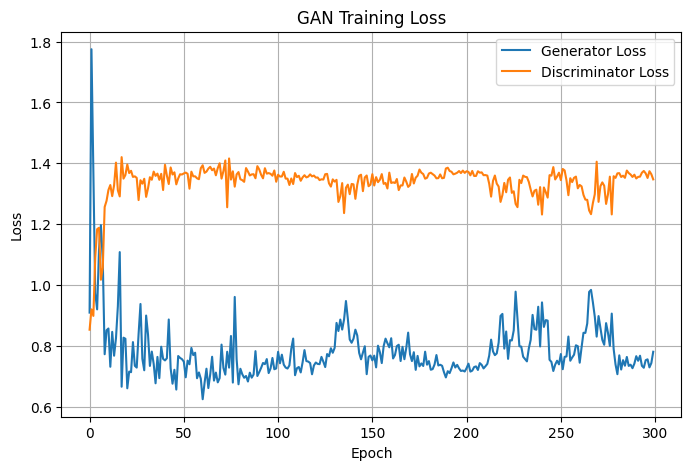

In [16]:
# ============================================================
# Plot training losses
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("GAN Training Loss")

plt.legend()

plt.grid(True)

plt.show()

## 1.12 Generate Synthetic Samples

After training, the Generator is evaluated by producing new synthetic samples from random latent vectors.

These generated samples are compared with the original sine-wave distribution to assess how well the Generator has learned the underlying data distribution.

In [17]:
# ============================================================
# Generate new samples
# ============================================================

generator.eval()

with torch.no_grad():

    noise = generate_noise(1000)

    generated_data = generator(noise).cpu()

## 1.13 Compare Real and Generated Samples

The final figure compares the original sine-wave dataset with the samples generated by the trained GAN.

A successful GAN should generate samples that closely follow the shape of the sine-wave while maintaining diversity across the distribution.

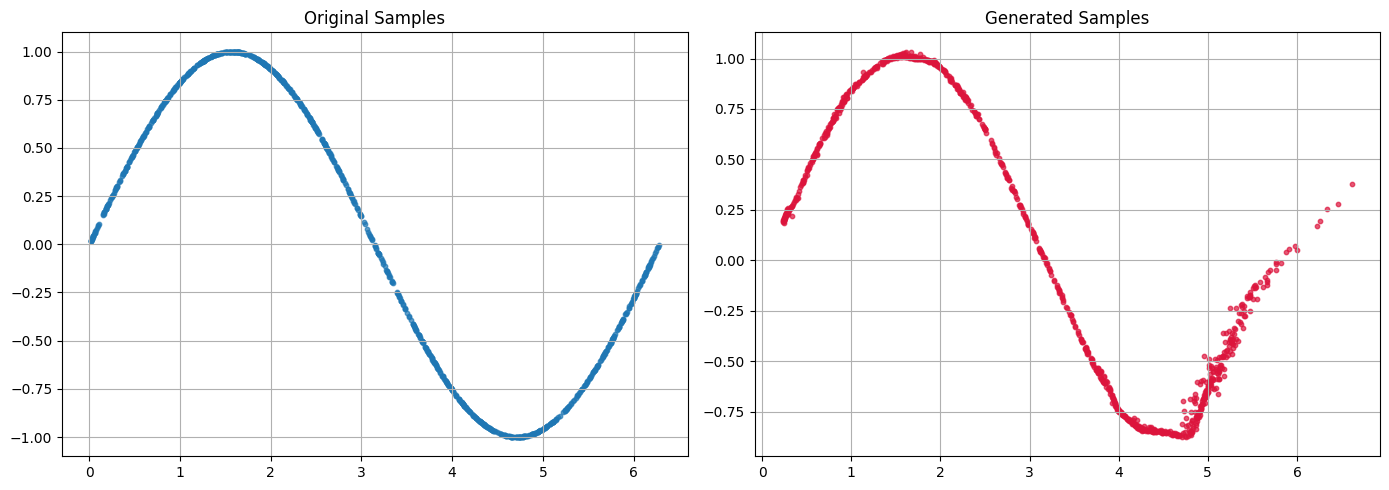

In [18]:
# ============================================================
# Compare real and generated samples
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(
    train_data[:,0],
    train_data[:,1],
    s=10,
    alpha=0.7
)

ax[0].set_title("Original Samples")

ax[0].grid(True)

ax[1].scatter(
    generated_data[:,0],
    generated_data[:,1],
    s=10,
    alpha=0.7,
    color="crimson"
)

ax[1].set_title("Generated Samples")

ax[1].grid(True)

plt.tight_layout()

plt.show()

# Part 1.2 – Modelling a Mixture of Gaussians

## Objective

The second task requires modelling a new synthetic two-dimensional distribution using a GAN.

A **Mixture of Gaussians** has been selected because it consists of multiple distinct clusters rather than a single continuous curve. This makes it an excellent benchmark for evaluating whether the Generator can learn several modes of a distribution simultaneously.

The GAN architecture from the previous section will initially be reused without modification.

## 1.14 Generate a Mixture of Gaussians Dataset

The dataset consists of four Gaussian clusters located at different positions in the two-dimensional plane.

Random noise is added around each cluster centre to produce realistic data samples.

In [19]:
# ============================================================
# Create Mixture of Gaussians Dataset
# ============================================================

def create_gaussian_dataset(samples_per_cluster=250):
    """
    Generate a 2D mixture of four Gaussian clusters.

    Parameters
    ----------
    samples_per_cluster : int
        Number of samples generated for each cluster.

    Returns
    -------
    Tensor
        Two-dimensional dataset.
    """

    centres = [
        (-2, -2),
        (-2, 2),
        (2, -2),
        (2, 2)
    ]

    data = []

    for cx, cy in centres:

        x = np.random.normal(cx, 0.30, samples_per_cluster)
        y = np.random.normal(cy, 0.30, samples_per_cluster)

        cluster = np.column_stack((x, y))

        data.append(cluster)

    data = np.vstack(data)

    np.random.shuffle(data)

    return torch.tensor(data, dtype=torch.float32)


gaussian_data = create_gaussian_dataset()

## 1.15 Visualise the New Dataset

Before training the GAN, the Mixture of Gaussians distribution is visualised.

The Generator will attempt to reproduce these four distinct clusters during adversarial training.

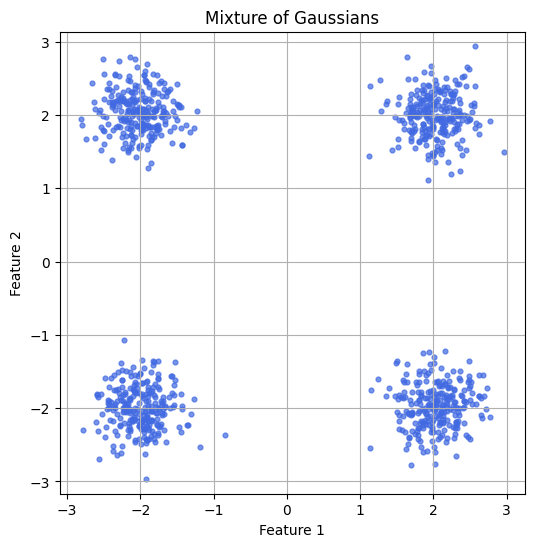

In [20]:
# ============================================================
# Visualise Gaussian Dataset
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(
    gaussian_data[:,0],
    gaussian_data[:,1],
    s=12,
    alpha=0.7,
    color="royalblue"
)

plt.title("Mixture of Gaussians")

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.grid(True)

plt.axis("equal")

plt.show()

## 1.16 Prepare the Training Data

The Gaussian dataset is converted into a PyTorch DataLoader to enable mini-batch training.

In [21]:
# ============================================================
# DataLoader
# ============================================================

labels = torch.zeros(len(gaussian_data))

gaussian_dataset = [
    (gaussian_data[i], labels[i])
    for i in range(len(gaussian_data))
]

gaussian_loader = DataLoader(
    gaussian_dataset,
    batch_size=32,
    shuffle=True
)

## 1.17 Reinitialise the GAN

To ensure a fair comparison with the sine-wave experiment, new Generator and Discriminator models are created and trained from scratch.

In [22]:
# ============================================================
# Create new models
# ============================================================

generator = Generator().to(device)

discriminator = Discriminator().to(device)

optimizer_generator = optim.Adam(
    generator.parameters(),
    lr=0.001
)

optimizer_discriminator = optim.Adam(
    discriminator.parameters(),
    lr=0.001
)

## 1.18 Train the GAN

The same adversarial training procedure used for the sine-wave dataset is now applied to the Mixture of Gaussians dataset.

In [23]:
# ============================================================
# Train on Gaussian Dataset
# ============================================================

num_epochs = 300

generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):

    epoch_g_loss = 0
    epoch_d_loss = 0

    for real_samples, _ in gaussian_loader:

        real_samples = real_samples.to(device)

        batch_size = real_samples.size(0)

        # Train Discriminator
        optimizer_discriminator.zero_grad()

        real_labels = torch.ones((batch_size,1), device=device)
        fake_labels = torch.zeros((batch_size,1), device=device)

        real_output = discriminator(real_samples)

        real_loss = loss_function(real_output, real_labels)

        noise = generate_noise(batch_size)

        fake_samples = generator(noise)

        fake_output = discriminator(fake_samples.detach())

        fake_loss = loss_function(fake_output, fake_labels)

        d_loss = real_loss + fake_loss

        d_loss.backward()

        optimizer_discriminator.step()

        # Train Generator
        optimizer_generator.zero_grad()

        noise = generate_noise(batch_size)

        generated = generator(noise)

        predictions = discriminator(generated)

        g_loss = loss_function(predictions, real_labels)

        g_loss.backward()

        optimizer_generator.step()

        epoch_g_loss += g_loss.item()

        epoch_d_loss += d_loss.item()

    generator_losses.append(epoch_g_loss/len(gaussian_loader))
    discriminator_losses.append(epoch_d_loss/len(gaussian_loader))

    if (epoch+1)%25==0:

        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"D:{discriminator_losses[-1]:.3f} "
            f"G:{generator_losses[-1]:.3f}"
        )

Epoch 25/300 D:0.599 G:1.744
Epoch 50/300 D:0.646 G:1.408
Epoch 75/300 D:0.582 G:1.811
Epoch 100/300 D:0.620 G:1.623
Epoch 125/300 D:0.624 G:1.547
Epoch 150/300 D:0.631 G:1.469
Epoch 175/300 D:0.629 G:1.626
Epoch 200/300 D:0.622 G:1.516
Epoch 225/300 D:0.626 G:1.465
Epoch 250/300 D:0.627 G:1.657
Epoch 275/300 D:0.623 G:1.573
Epoch 300/300 D:0.633 G:1.579


## 1.19 Compare the Real and Generated Gaussian Distributions

After training, the Generator produces synthetic samples from random latent vectors.

These samples are compared directly with the original Mixture of Gaussians to evaluate how well the Generator has learned the multiple modes of the distribution.

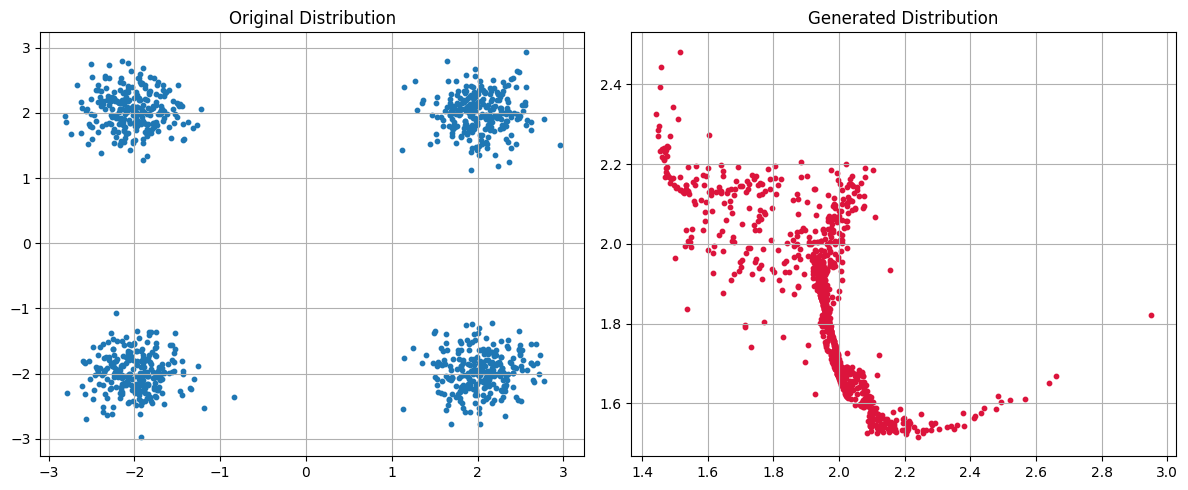

In [24]:
# ============================================================
# Compare Real vs Generated
# ============================================================

generator.eval()

with torch.no_grad():

    noise = generate_noise(1000)

    fake = generator(noise).cpu()

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(
    gaussian_data[:,0],
    gaussian_data[:,1],
    s=10
)

ax[0].set_title("Original Distribution")

ax[0].grid(True)

ax[1].scatter(
    fake[:,0],
    fake[:,1],
    s=10,
    color="crimson"
)

ax[1].set_title("Generated Distribution")

ax[1].grid(True)

plt.tight_layout()

plt.show()

# Part 1.3 – Improving the GAN Architecture

## Objective

The original Generator struggled to model all four Gaussian clusters simultaneously, resulting in an incomplete representation of the data distribution.

To improve performance, the Generator and Discriminator architectures are modified.

The main changes include:

- Replacing ReLU with LeakyReLU
- Adding Batch Normalisation
- Increasing the depth of the Generator

These modifications are expected to stabilise adversarial training and reduce mode collapse.

In [25]:
# ============================================================
# Improved Generator
# ============================================================

class ImprovedGenerator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(2,64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64,128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64,2)

        )

    def forward(self,x):

        return self.model(x)

In [26]:
# ============================================================
# Improved Discriminator
# ============================================================

class ImprovedDiscriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(2,256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256,128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.LeakyReLU(0.2),

            nn.Linear(64,1),
            nn.Sigmoid()

        )

    def forward(self,x):

        return self.model(x)

## 1.20 Train the Improved GAN

The improved Generator and Discriminator are trained using the same Mixture of Gaussians dataset.

The training procedure remains unchanged, allowing a direct comparison between the original and modified architectures.

In [27]:
generator = ImprovedGenerator().to(device)
discriminator = ImprovedDiscriminator().to(device)

optimizer_generator = optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))
optimizer_discriminator = optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [28]:
# ============================================================
# Train on improved Gaussian Dataset
# ============================================================

num_epochs = 500

generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):

    epoch_g_loss = 0
    epoch_d_loss = 0

    for real_samples, _ in gaussian_loader:

        real_samples = real_samples.to(device)

        batch_size = real_samples.size(0)

        # Train Discriminator
        optimizer_discriminator.zero_grad()

        real_labels = torch.ones((batch_size,1), device=device)
        fake_labels = torch.zeros((batch_size,1), device=device)

        real_output = discriminator(real_samples)

        real_loss = loss_function(real_output, real_labels)

        noise = generate_noise(batch_size)

        fake_samples = generator(noise)

        fake_output = discriminator(fake_samples.detach())

        fake_loss = loss_function(fake_output, fake_labels)

        d_loss = real_loss + fake_loss

        d_loss.backward()

        optimizer_discriminator.step()

        # Train Generator
        optimizer_generator.zero_grad()

        noise = generate_noise(batch_size)

        generated = generator(noise)

        predictions = discriminator(generated)

        g_loss = loss_function(predictions, real_labels)

        g_loss.backward()

        optimizer_generator.step()

        epoch_g_loss += g_loss.item()

        epoch_d_loss += d_loss.item()

    generator_losses.append(epoch_g_loss/len(gaussian_loader))
    discriminator_losses.append(epoch_d_loss/len(gaussian_loader))

    if (epoch+1)%25==0:

        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"D:{discriminator_losses[-1]:.3f} "
            f"G:{generator_losses[-1]:.3f}"
        )

Epoch 25/500 D:1.386 G:0.700
Epoch 50/500 D:1.379 G:0.705
Epoch 75/500 D:1.380 G:0.696
Epoch 100/500 D:1.377 G:0.699
Epoch 125/500 D:1.375 G:0.700
Epoch 150/500 D:1.371 G:0.709
Epoch 175/500 D:1.380 G:0.701
Epoch 200/500 D:1.384 G:0.697
Epoch 225/500 D:1.379 G:0.705
Epoch 250/500 D:1.375 G:0.705
Epoch 275/500 D:1.378 G:0.719
Epoch 300/500 D:1.378 G:0.715
Epoch 325/500 D:1.382 G:0.707
Epoch 350/500 D:1.378 G:0.708
Epoch 375/500 D:1.379 G:0.714
Epoch 400/500 D:1.380 G:0.733
Epoch 425/500 D:1.374 G:0.728
Epoch 450/500 D:1.380 G:0.710
Epoch 475/500 D:1.365 G:0.761
Epoch 500/500 D:1.382 G:0.718


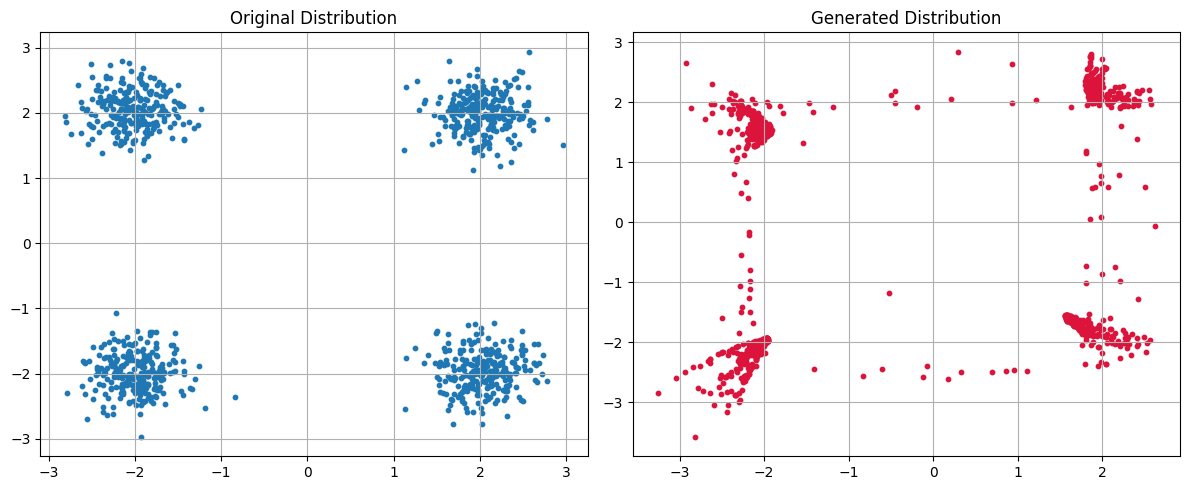

In [29]:
# ============================================================
# Compare Real vs Generated
# ============================================================

generator.eval()

with torch.no_grad():

    noise = generate_noise(1000)

    fake = generator(noise).cpu()

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(
    gaussian_data[:,0],
    gaussian_data[:,1],
    s=10
)

ax[0].set_title("Original Distribution")

ax[0].grid(True)

ax[1].scatter(
    fake[:,0],
    fake[:,1],
    s=10,
    color="crimson"
)

ax[1].set_title("Generated Distribution")

ax[1].grid(True)

plt.tight_layout()

plt.show()

# Part 2.1 – Optical Coherence Tomography (OCTMNIST)

## Objective

The objective of this section is to train a Deep Convolutional Generative Adversarial Network (DCGAN) to generate synthetic Optical Coherence Tomography (OCT) retinal images.

Unlike the simple two-dimensional datasets used in Part 1, OCTMNIST contains grayscale retinal images. Therefore, convolutional neural networks are used for both the Generator and Discriminator, allowing the model to learn spatial image features more effectively.

The quality of the generated images will be evaluated visually and quantitatively using the Fréchet Inception Distance (FID).

## 2.1.1 Import Required Libraries

The following libraries are used for loading the OCTMNIST dataset, constructing the DCGAN architecture, training the model, and visualising the generated retinal images.

The **MedMNIST** package provides direct access to the OCTMNIST dataset, while **Torchvision** supplies useful image transformations and utilities.

In [30]:
# ============================================================
# Import libraries
# ============================================================

# Install MedMNIST if required
!pip install -q medmnist

import medmnist
from medmnist import INFO, OCTMNIST

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.0 MB/s eta 0:00:00


## 2.1.2 Load the OCTMNIST Dataset

The OCTMNIST dataset is downloaded automatically using the MedMNIST package.

The dataset contains retinal OCT images belonging to four diagnostic classes.

Separate datasets are created for training, validation and testing.

In [31]:
# ============================================================
# Load OCTMNIST
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = OCTMNIST(
    split="train",
    transform=transform,
    download=True
)

val_dataset = OCTMNIST(
    split="val",
    transform=transform,
    download=True
)

test_dataset = OCTMNIST(
    split="test",
    transform=transform,
    download=True
)

print("Training Images :", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images :", len(test_dataset))

100%|██████████| 54.9M/54.9M [00:17<00:00, 3.21MB/s]


Training Images : 97477
Validation Images: 10832
Testing Images : 1000


## 2.1.3 Explore the Dataset

Before training the GAN, the dataset is explored to understand its size, class distribution, and image dimensions.

Visual inspection of several retinal images provides an understanding of the structures that the Generator will attempt to learn.

In [32]:
# ============================================================
# Dataset information
# ============================================================

info = INFO["octmnist"]

print("Dataset Information")
print("-------------------")

print("Task:", info["task"])

print("Number of Classes:", len(info["label"]))

print("Labels:")

for key, value in info["label"].items():
    print(f"{key}: {value}")

Dataset Information
-------------------
Task: multi-class
Number of Classes: 4
Labels:
0: choroidal neovascularization
1: diabetic macular edema
2: drusen
3: normal


## 2.1.4 Visualise Sample Images

A selection of retinal OCT images is displayed below.

These images illustrate the appearance of the training data and provide a reference for evaluating the quality of the synthetic images generated by the DCGAN.

/tmp/ipykernel_1375/2488154631.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  info["label"][str(int(label))]


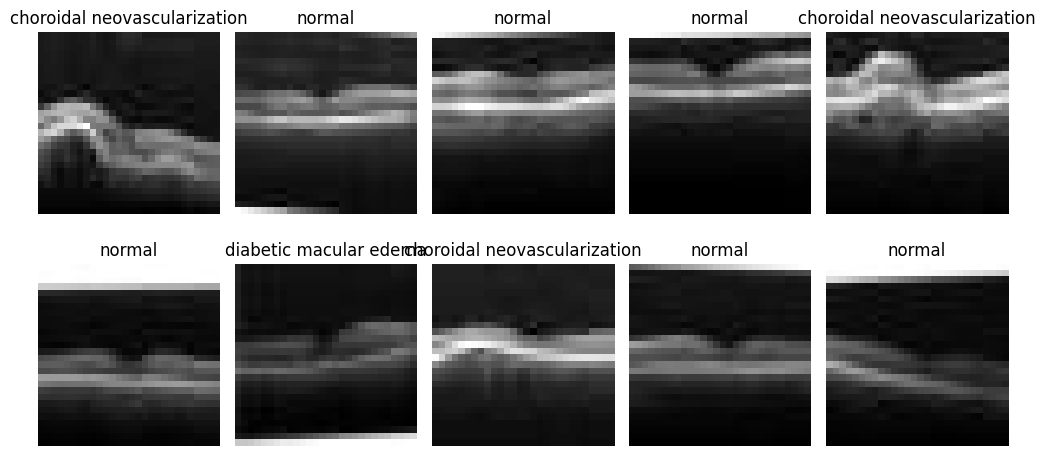

In [33]:
# ============================================================
# Display sample images
# ============================================================

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        info["label"][str(int(label))]
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

## 2.1.5 Examine the Class Distribution

Understanding the class distribution helps determine whether the dataset is balanced.

Although the GAN is trained without labels, analysing the class frequencies provides useful insight into the composition of the dataset.

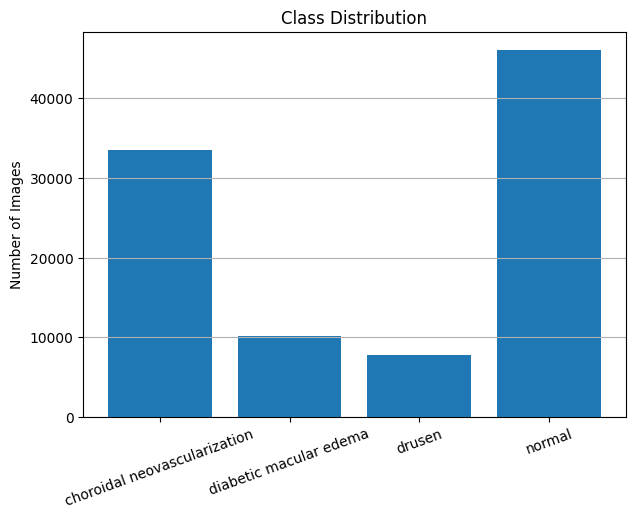

In [34]:
# ============================================================
# Class distribution
# ============================================================

labels = np.array(train_dataset.labels).flatten()

unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(7,5))

plt.bar(unique, counts)

plt.xticks(unique,
           [info["label"][str(i)] for i in unique],
           rotation=20)

plt.ylabel("Number of Images")

plt.title("Class Distribution")

plt.grid(axis="y")

plt.show()

## 2.1.6 Prepare the DataLoader

The training images are loaded into a PyTorch DataLoader to enable mini-batch training. Images are shuffled at each epoch to improve the stability of adversarial learning.

In [35]:
# ============================================================
# DataLoader
# ============================================================

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

print("Number of batches:", len(train_loader))

Number of batches: 761


## 2.1.7 Define the DCGAN Generator

The Generator transforms a 100-dimensional random noise vector into a synthetic 28×28 grayscale retinal image.

A sequence of transposed convolution layers is used to progressively increase the spatial resolution of the generated image.

In [36]:
# ============================================================
# DCGAN Generator
# ============================================================

latent_dim = 100

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(latent_dim,256,7,1,0,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64,1,3,1,1),

            nn.Tanh()

        )

    def forward(self,x):

        return self.main(x)

## 2.1.8 Define the DCGAN Discriminator

The Discriminator receives either a real retinal image or a generated image and predicts the probability that the image is real.

Convolutional layers are used to extract spatial image features while LeakyReLU activation functions improve training stability.

In [37]:
# ============================================================
# DCGAN Discriminator
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.main = nn.Sequential(

            nn.Conv2d(1,64,4,2,1,bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128,256,3,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            nn.Linear(256*4*4,1),

            nn.Sigmoid()

        )

    def forward(self,x):

        return self.main(x)

## 2.1.9 Initialise Model Weights

Following the original DCGAN paper, convolutional and batch normalisation layers are initialised using a normal distribution. Proper weight initialisation improves convergence and training stability.

In [38]:
# ============================================================
# Weight Initialization
# ============================================================

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:

        nn.init.normal_(m.weight.data,0.0,0.02)

    elif classname.find("BatchNorm") != -1:

        nn.init.normal_(m.weight.data,1.0,0.02)

        nn.init.constant_(m.bias.data,0)

## 2.1.10 Create the DCGAN Models

The Generator and Discriminator are created, initialised, and configured to use the Adam optimiser with the hyperparameters recommended for DCGAN training.

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

print(generator)
print()
print(discriminator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), pad

## 2.1.11 Train the DCGAN

The Generator and Discriminator are trained using the standard adversarial learning procedure.

The Discriminator is first trained to distinguish between real and generated retinal images. The Generator is then updated to produce increasingly realistic synthetic images that can fool the Discriminator.

Generator and Discriminator losses are recorded throughout training to monitor convergence.

In [40]:
# ============================================================
# Train DCGAN
# ============================================================

num_epochs = 20

G_losses = []
D_losses = []

fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

for epoch in range(num_epochs):

    running_G = 0
    running_D = 0

    for images, _ in train_loader:

        real_images = images.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size,1,device=device)
        fake_labels = torch.zeros(batch_size,1,device=device)

        ####################################################
        # Train Discriminator
        ####################################################

        optimizer_D.zero_grad()

        output_real = discriminator(real_images)

        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size, latent_dim,1,1, device=device)

        fake_images = generator(noise)

        output_fake = discriminator(fake_images.detach())

        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()

        ####################################################
        # Train Generator
        ####################################################

        optimizer_G.zero_grad()

        output = discriminator(fake_images)

        loss_G = criterion(output, real_labels)

        loss_G.backward()

        optimizer_G.step()

        running_G += loss_G.item()

        running_D += loss_D.item()

    G_losses.append(running_G/len(train_loader))
    D_losses.append(running_D/len(train_loader))

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"D Loss: {D_losses[-1]:.4f} "
        f"G Loss: {G_losses[-1]:.4f}"
    )

Epoch [1/20] D Loss: 0.6201 G Loss: 2.4247
Epoch [2/20] D Loss: 0.8995 G Loss: 1.5817
Epoch [3/20] D Loss: 0.7927 G Loss: 1.7248
Epoch [4/20] D Loss: 0.7897 G Loss: 1.7794
Epoch [5/20] D Loss: 0.7950 G Loss: 1.8517
Epoch [6/20] D Loss: 0.7069 G Loss: 2.0471
Epoch [7/20] D Loss: 0.6165 G Loss: 2.3011
Epoch [8/20] D Loss: 0.4704 G Loss: 2.6683
Epoch [9/20] D Loss: 0.4897 G Loss: 2.8295
Epoch [10/20] D Loss: 0.3201 G Loss: 3.0384
Epoch [11/20] D Loss: 0.3456 G Loss: 3.2145
Epoch [12/20] D Loss: 0.2889 G Loss: 3.4530
Epoch [13/20] D Loss: 0.2502 G Loss: 3.5834
Epoch [14/20] D Loss: 0.2565 G Loss: 3.7245
Epoch [15/20] D Loss: 0.3201 G Loss: 3.6933
Epoch [16/20] D Loss: 0.2266 G Loss: 3.9659
Epoch [17/20] D Loss: 0.2138 G Loss: 3.9658
Epoch [18/20] D Loss: 0.3765 G Loss: 3.8660
Epoch [19/20] D Loss: 0.2080 G Loss: 4.1063
Epoch [20/20] D Loss: 0.2033 G Loss: 4.2727


## 2.1.12 Plot the Training Losses

The Generator and Discriminator losses are plotted over the training epochs to assess the stability of adversarial learning.

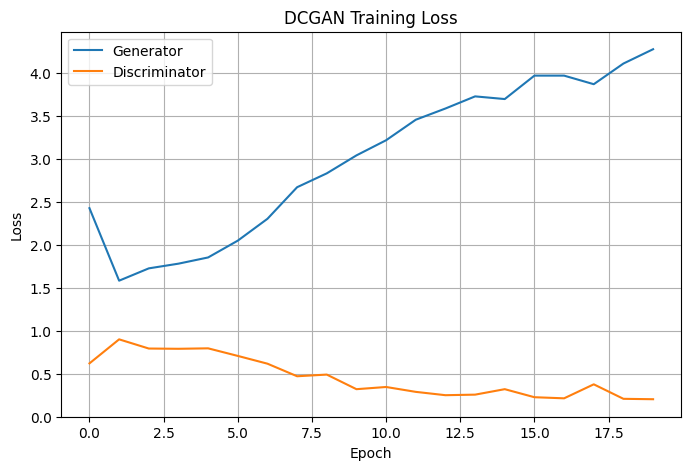

In [41]:
plt.figure(figsize=(8,5))

plt.plot(G_losses,label="Generator")
plt.plot(D_losses,label="Discriminator")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("DCGAN Training Loss")

plt.legend()

plt.grid(True)

plt.show()

## 2.1.13 Generate Synthetic Retinal Images

After training the DCGAN, the Generator is used to produce synthetic retinal OCT images from random latent vectors.

These images provide a qualitative assessment of how well the Generator has learned the retinal image distribution.

In [42]:
# ============================================================
# Generate Synthetic OCT Images
# ============================================================

generator.eval()

with torch.no_grad():

    noise = torch.randn(64, latent_dim, 1, 1, device=device)

    fake_images = generator(noise).cpu()

print(fake_images.shape)

torch.Size([64, 1, 28, 28])


## 2.1.14 Visualise Generated Images

A grid of generated retinal OCT images is displayed. The images are inspected visually to determine whether the Generator has learned meaningful retinal structures.

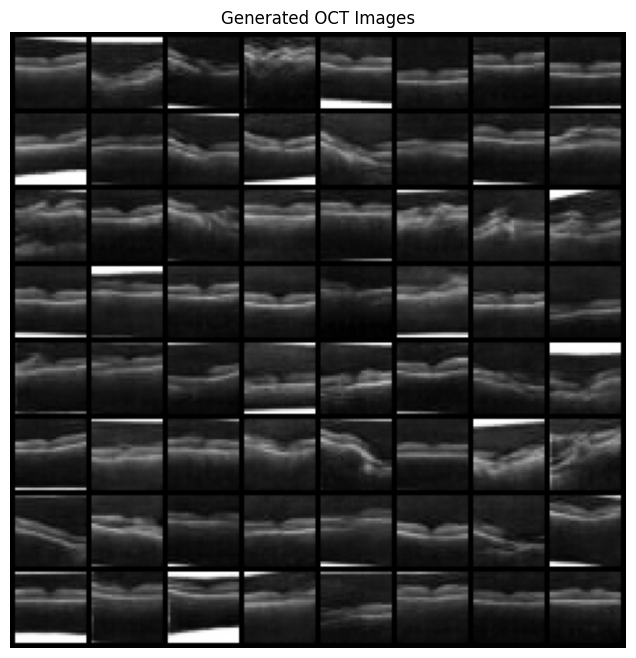

In [43]:
# ============================================================
# Display Generated Images
# ============================================================

grid = make_grid(
    fake_images,
    nrow=8,
    normalize=True
)

plt.figure(figsize=(8,8))

plt.imshow(
    np.transpose(grid,(1,2,0)),
    cmap="gray"
)

plt.title("Generated OCT Images")

plt.axis("off")

plt.show()

## 2.1.15 Compare Real and Generated Images

Real retinal OCT images and generated images are displayed side by side for visual comparison. This provides an initial qualitative evaluation of the Generator's performance.

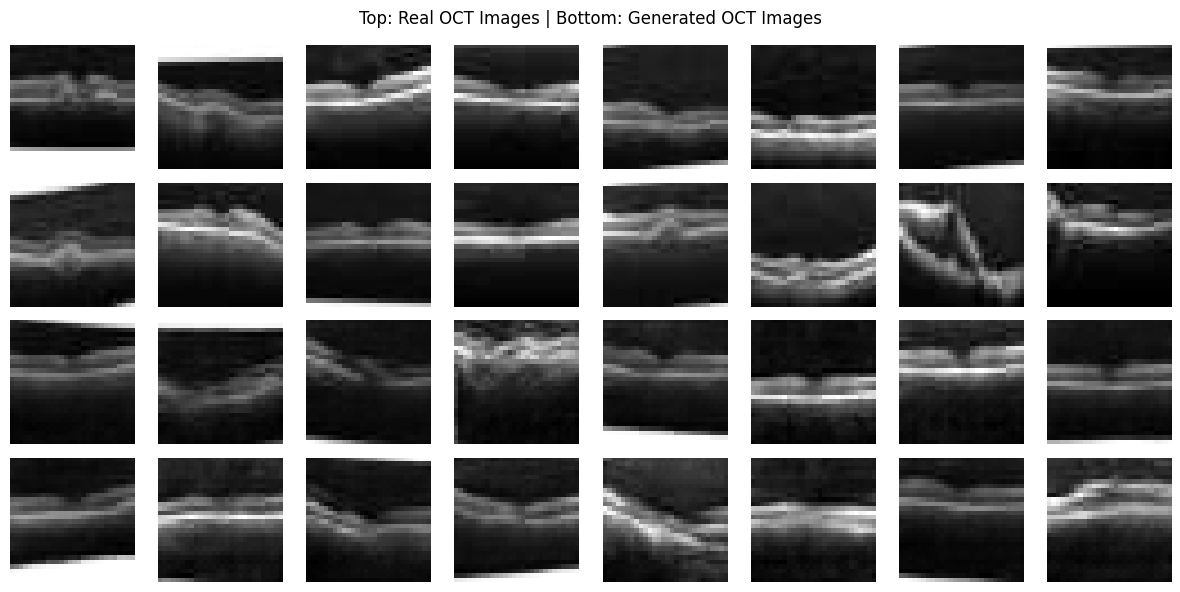

In [44]:
# ============================================================
# Real vs Generated Images
# ============================================================

real_batch = next(iter(train_loader))[0][:16]

fig, axes = plt.subplots(4,8, figsize=(12,6))

# Real images
for i in range(16):

    axes[i//8, i%8].imshow(
        real_batch[i].squeeze(),
        cmap="gray"
    )

    axes[i//8, i%8].axis("off")

# Generated images
for i in range(16):

    axes[(i//8)+2, i%8].imshow(
        fake_images[i].squeeze(),
        cmap="gray"
    )

    axes[(i//8)+2, i%8].axis("off")

plt.suptitle("Top: Real OCT Images | Bottom: Generated OCT Images")

plt.tight_layout()

plt.show()

## 2.1.16 Evaluate Image Quality using the Fréchet Inception Distance (FID)

The Fréchet Inception Distance (FID) is used to quantitatively evaluate the similarity between real and generated images.

Lower FID scores indicate that the generated images more closely resemble the real image distribution.

In [45]:
# Install TorchMetrics if required
!pip install -q torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.6 MB/s eta 0:00:00


In [46]:
!pip install -q torchmetrics torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.7 MB/s eta 0:00:00


In [47]:
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=64).to(device)

generator.eval()

real_count = 0

with torch.no_grad():

    for real_images, _ in train_loader:

        real_images = real_images.to(device)

        fake_noise = torch.randn(real_images.size(0), latent_dim, 1, 1, device=device)
        fake_images = generator(fake_noise)

        # Convert grayscale to RGB
        real = real_images.repeat(1,3,1,1)
        fake = fake_images.repeat(1,3,1,1)

        # Convert [-1,1] -> [0,255]
        real = ((real + 1) * 127.5).clamp(0,255).to(torch.uint8)
        fake = ((fake + 1) * 127.5).clamp(0,255).to(torch.uint8)

        fid.update(real, real=True)
        fid.update(fake, real=False)

        real_count += real_images.size(0)

        if real_count >= 1000:
            break

score = fid.compute()

print("FID Score:", float(score))

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 227MB/s]


FID Score: 0.10912978649139404


# Part 2.2 – Cybersecurity: Synthetic Network Traffic using CICIDS2017

## Objective

The objective of this section is to train a Generative Adversarial Network (GAN) to generate synthetic network traffic records using the CICIDS2017 intrusion detection dataset.

Unlike the previous image-based application, this dataset consists of numerical network traffic features. Therefore, a fully connected GAN is used instead of a convolutional DCGAN.

The generated feature vectors will later be compared with the original data using dimensionality reduction techniques such as Principal Component Analysis (PCA).

## 2.2.1 Load and Explore the Dataset

The CICIDS2017 dataset is a benchmark dataset for intrusion detection research. It contains network traffic collected over five working days and includes both normal network traffic (BENIGN) and several cyber-attacks such as DoS, DDoS, PortScan, Web Attacks and Botnet attacks.

The complete dataset is distributed as multiple CSV files, with each file representing network traffic collected on a different day.

For this assignment, the GAN is trained using only the **Wednesday-workingHours.pcap_ISCX.csv** file, as required in the assignment specification. This file contains BENIGN traffic together with several Denial-of-Service (DoS) attack classes.

The following section explores the dataset structure, features and class distribution before preprocessing.

In [48]:
# ============================================================
# Load Dataset
# ============================================================

import kagglehub
import pandas as pd
import os

# Download the dataset
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Dataset downloaded to:", path)

# Load the Wednesday file
csv_path = os.path.join(path, "Wednesday-workingHours.pcap_ISCX.csv")

df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset downloaded to: /kaggle/input/network-intrusion-dataset
Dataset Shape: (692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [49]:
# ============================================================
# Dataset Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             692703 non-null  int64  
 1    Flow Duration                692703 non-null  int64  
 2    Total Fwd Packets            692703 non-null  int64  
 3    Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets   692703 non-null  int64  
 5    Total Length of Bwd Packets  692703 non-null  int64  
 6    Fwd Packet Length Max        692703 non-null  int64  
 7    Fwd Packet Length Min        692703 non-null  int64  
 8    Fwd Packet Length Mean       692703 non-null  float64
 9    Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max         692703 non-null  int64  
 11   Bwd Packet Length Min        692703 non-null  int64  
 12   Bwd Packet Length Mean       692703 non-nul

In [50]:
# ============================================================
# Missing Values
# ============================================================

print(df.isnull().sum().sort_values(ascending=False).head(15))

Flow Bytes/s                    1008
 Flow Duration                     0
 Destination Port                  0
 Total Backward Packets            0
Total Length of Fwd Packets        0
 Total Length of Bwd Packets       0
 Total Fwd Packets                 0
 Fwd Packet Length Max             0
 Fwd Packet Length Min             0
 Fwd Packet Length Std             0
 Fwd Packet Length Mean            0
Bwd Packet Length Max              0
 Bwd Packet Length Min             0
 Bwd Packet Length Mean            0
 Bwd Packet Length Std             0
dtype: int64


In [51]:
# ============================================================
# Class Distribution
# ============================================================

print(df[" Label"].value_counts())

 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


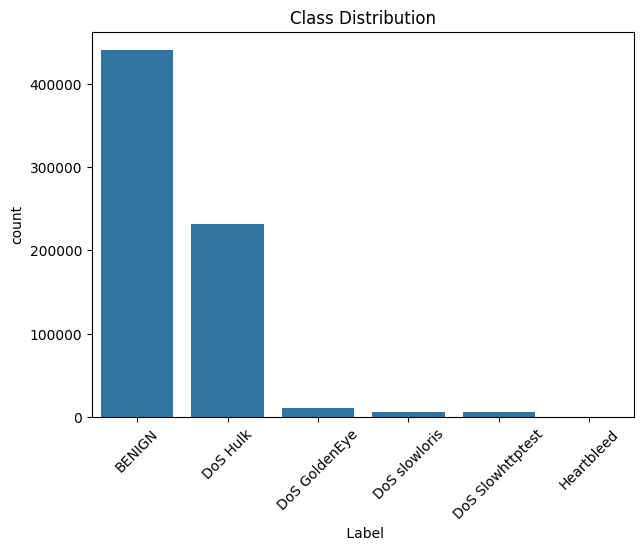

In [52]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=" Label",
    order=df[" Label"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Class Distribution")

plt.show()

## 2.2.2 Preprocess the Dataset

Before training the GAN, the dataset is preprocessed by removing missing values, selecting only the BENIGN and DoS attack classes, encoding the labels, and normalising the numerical features.

Since the GAN generates numerical feature vectors rather than labels, only the feature matrix is used during training.

In [53]:
# ============================================================
# Remove Missing Values
# ============================================================

df = df.dropna()

print("Dataset Shape:", df.shape)

Dataset Shape: (691695, 79)


In [54]:
# ============================================================
# Check Available Classes
# ============================================================

print(df[" Label"].value_counts())

 Label
BENIGN              439972
DoS Hulk            230124
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


## 2.2.3 Prepare the Feature Matrix

The GAN is trained using only the numerical network traffic features. The label column is removed, non-finite values are handled, and all features are normalised using Min-Max scaling.

Feature normalisation ensures that every input variable contributes equally during adversarial training.

In [55]:
# ============================================================
# Prepare Features
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Remove label column
X = df.drop(columns=[" Label"])

# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Remove remaining missing values
X = X.dropna()

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (691406, 78)


In [56]:
# ============================================================
# Normalize Features
# ============================================================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (691406, 78)


## 2.2.4 Create the PyTorch Dataset

The normalised feature matrix is converted into a PyTorch Dataset and DataLoader to enable mini-batch GAN training.

In [57]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

dataset = TensorDataset(X_tensor)

batch_size = 256

cyber_train_loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True
)

feature_dim = X_tensor.shape[1]

print("Feature Dimension:", feature_dim)
print("Number of batches:", len(train_loader))

Feature Dimension: 78
Number of batches: 761


## 2.2.5 Define the Generator

The Generator learns to transform a random latent vector into a synthetic network traffic feature vector.

Fully connected layers are used because the CICIDS2017 dataset consists of tabular numerical data rather than images.

In [58]:
# ============================================================
# Generator
# ============================================================

latent_dim = 64

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,feature_dim),

            nn.Sigmoid()

        )

    def forward(self,x):

        return self.model(x)

## 2.2.6 Define the Discriminator

The Discriminator receives either a real network traffic feature vector or a generated feature vector and predicts whether it is real or synthetic.

A fully connected neural network is used for binary classification.

In [59]:
# ============================================================
# Discriminator
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(feature_dim,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,128),
            nn.LeakyReLU(0.2),

            nn.Linear(128,1),

            nn.Sigmoid()

        )

    def forward(self,x):

        return self.model(x)

## 2.2.7 Create the GAN Models

The Generator and Discriminator are initialised and optimised using the Adam optimiser. Binary Cross-Entropy loss is used as the adversarial objective.

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0001,
    betas=(0.5,0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0001,
    betas=(0.5,0.999)
)

print(generator)
print()
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=78, bias=True)
    (5): Sigmoid()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 2.2.8 Train the GAN

The Generator and Discriminator are trained using the standard adversarial learning procedure.

The Discriminator learns to distinguish real network traffic feature vectors from synthetic feature vectors, while the Generator attempts to produce realistic synthetic traffic capable of fooling the Discriminator.

The Generator and Discriminator losses are recorded after each training epoch to monitor learning progress.

In [61]:
# ============================================================
# Train GAN
# ============================================================

num_epochs = 30

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    running_G = 0
    running_D = 0

    for (real_data,) in cyber_train_loader:

        real_data = real_data.to(device)

        batch_size = real_data.size(0)

        real_labels = torch.ones(batch_size,1,device=device)
        fake_labels = torch.zeros(batch_size,1,device=device)

        ####################################################
        # Train Discriminator
        ####################################################

        optimizer_D.zero_grad()

        output_real = discriminator(real_data)

        loss_real = criterion(output_real,real_labels)

        noise = torch.randn(batch_size,latent_dim,device=device)

        fake_data = generator(noise)

        output_fake = discriminator(fake_data.detach())

        loss_fake = criterion(output_fake,fake_labels)

        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()

        ####################################################
        # Train Generator
        ####################################################

        optimizer_G.zero_grad()

        output = discriminator(fake_data)

        loss_G = criterion(output,real_labels)

        loss_G.backward()

        optimizer_G.step()

        running_D += loss_D.item()
        running_G += loss_G.item()

    D_losses.append(running_D/len(train_loader))
    G_losses.append(running_G/len(train_loader))

    if (epoch+1)%5==0:

        print(f"Epoch {epoch+1}/{num_epochs}  D:{D_losses[-1]:.4f}  G:{G_losses[-1]:.4f}")

Epoch 5/30  D:2.4210  G:5.3235
Epoch 10/30  D:2.1012  G:6.8626
Epoch 15/30  D:2.2693  G:6.6598
Epoch 20/30  D:2.3451  G:5.4849
Epoch 25/30  D:2.3568  G:5.4763
Epoch 30/30  D:3.0627  G:9.9318


## 2.2.9 Training Loss Curves

The Generator and Discriminator losses are plotted to evaluate the stability of adversarial learning throughout the training process.

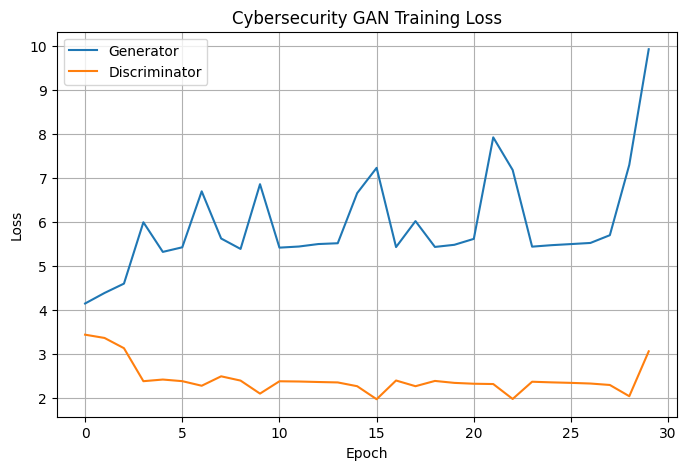

In [62]:
plt.figure(figsize=(8,5))

plt.plot(G_losses,label="Generator")
plt.plot(D_losses,label="Discriminator")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Cybersecurity GAN Training Loss")

plt.grid(True)

plt.legend()

plt.show()

## 2.2.10 Generate Synthetic Network Traffic

After training, the Generator is used to produce synthetic network traffic feature vectors from random latent vectors.

These synthetic samples are compared with the original traffic using Principal Component Analysis (PCA).

In [63]:
# ============================================================
# Generate Synthetic Traffic
# ============================================================

generator.eval()

num_samples = 5000

with torch.no_grad():

    noise = torch.randn(num_samples, latent_dim, device=device)

    fake_samples = generator(noise).cpu().numpy()

print(fake_samples.shape)

(5000, 78)


## 2.2.11 Visualise Real and Generated Data using PCA

Principal Component Analysis (PCA) is applied to project both the real and generated feature vectors into two dimensions.

If the Generator has learned the data distribution successfully, the generated samples should overlap substantially with the real samples.

In [64]:
# ============================================================
# PCA Visualisation
# ============================================================

from sklearn.decomposition import PCA

real_subset = X_scaled[:5000]

combined = np.vstack((real_subset, fake_samples))

pca = PCA(n_components=2)

combined_pca = pca.fit_transform(combined)

real_pca = combined_pca[:5000]

fake_pca = combined_pca[5000:]

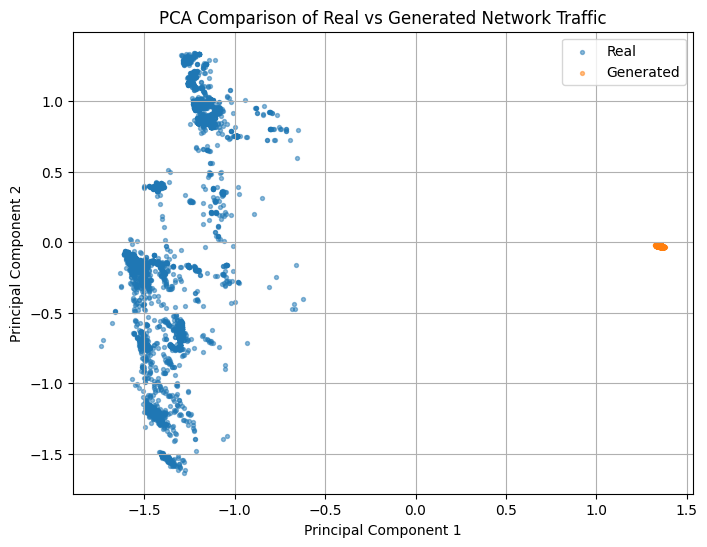

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(
    real_pca[:,0],
    real_pca[:,1],
    s=8,
    alpha=0.5,
    label="Real"
)

plt.scatter(
    fake_pca[:,0],
    fake_pca[:,1],
    s=8,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Comparison of Real vs Generated Network Traffic")

plt.legend()

plt.grid(True)

plt.show()

## 2.2.12 Discussion

The PCA projection provides a qualitative assessment of how closely the generated network traffic matches the original dataset.

Greater overlap between the two point clouds indicates that the Generator has successfully learned the underlying feature distribution. Visible separation or isolated clusters suggest that additional training or more advanced GAN architectures may improve the realism of the generated traffic.

# Part 2.3 – Creative AI: QuickDraw Birthday Cake Sketch Generation

## Objective

The objective of this section is to train a Deep Convolutional Generative Adversarial Network (DCGAN) to generate realistic birthday cake sketches using Google's QuickDraw dataset.

Unlike the cybersecurity application, this dataset consists of images represented as 28×28 grayscale sketches. Therefore, a convolutional GAN architecture is used to learn the underlying distribution of the sketches and generate new synthetic birthday cake drawings.

## 2.3.1 Load and Explore the Dataset

The QuickDraw birthday cake dataset is loaded and reshaped into 28×28 grayscale images. Sample sketches are visualised to understand the characteristics of the training data.

In [66]:
# ============================================================
# Import Libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

In [67]:
# ============================================================
# Load Dataset
# ============================================================

import urllib.request
import numpy as np

url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/birthday%20cake.npy"

urllib.request.urlretrieve(
    url,
    "full_numpy_bitmap_birthday_cake.npy"
)

cakes = np.load("full_numpy_bitmap_birthday_cake.npy")

print("Dataset Shape:", cakes.shape)
print("Data Type:", cakes.dtype)

Dataset Shape: (144982, 784)
Data Type: uint8


In [68]:
# ============================================================
# Reshape Images
# ============================================================

cakes = cakes.reshape(-1,28,28)

print("Image Shape:", cakes.shape)

Image Shape: (144982, 28, 28)


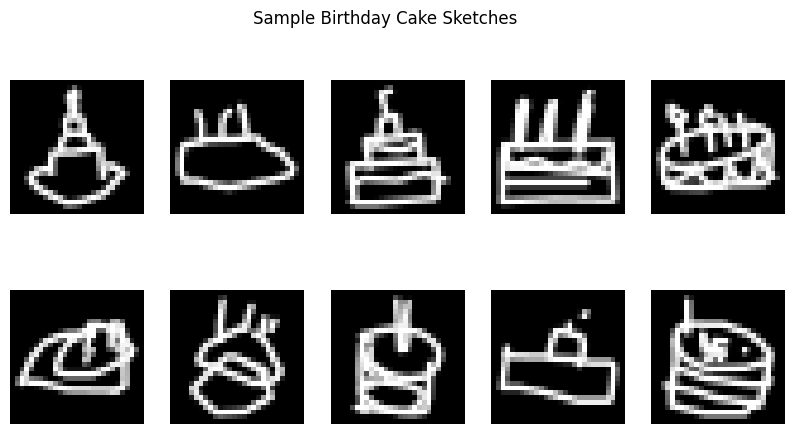

In [69]:
# ============================================================
# Display Sample Sketches
# ============================================================

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(cakes[i], cmap="gray")

    plt.axis("off")

plt.suptitle("Sample Birthday Cake Sketches")

plt.show()

## 2.3.2 Prepare the Dataset

The pixel values are normalised from the original range [0,255] to [-1,1], which is suitable for the Tanh activation function used in the Generator.

The images are then converted into a PyTorch Dataset and DataLoader for mini-batch training.

In [70]:
# ============================================================
# Normalize Images
# ============================================================

cakes = cakes.astype(np.float32)

cakes = (cakes - 127.5) / 127.5

In [71]:
# ============================================================
# Create Dataset
# ============================================================

cakes_tensor = torch.tensor(cakes).unsqueeze(1)

batch_size = 128

dataset = torch.utils.data.TensorDataset(cakes_tensor)

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Training Images:", len(dataset))
print("Number of batches:", len(train_loader))

Training Images: 144982
Number of batches: 1133


## 2.3.3 Build the DCGAN

A Deep Convolutional Generative Adversarial Network (DCGAN) is implemented to generate realistic birthday cake sketches.

The Generator transforms random latent vectors into 28×28 grayscale images, while the Discriminator learns to distinguish between real and generated sketches.

In [72]:
import torch.nn as nn

latent_dim = 100

# ============================================================
# Generator
# ============================================================

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(latent_dim,256,7,1,0,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64,1,3,1,1),

            nn.Tanh()

        )

    def forward(self,x):
        return self.main(x)

## 2.3.4 Define the Discriminator

The Discriminator receives either a real birthday cake sketch or a generated sketch and predicts whether the image is authentic or synthetic.

In [73]:
# ============================================================
# Discriminator
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.main = nn.Sequential(

            nn.Conv2d(1,64,4,2,1,bias=False),
            nn.LeakyReLU(0.2,True),

            nn.Conv2d(64,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2,True),

            nn.Conv2d(128,256,3,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2,True),

            nn.Flatten(),

            nn.Linear(256*4*4,1),

            nn.Sigmoid()

        )

    def forward(self,x):
        return self.main(x)

## 2.3.5 Initialise the Models

The Generator and Discriminator are initialised and optimised using the Adam optimiser with Binary Cross-Entropy loss.

In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

print(generator)
print()
print(discriminator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), pad

## 2.3.6 Train the DCGAN

The Generator and Discriminator are trained simultaneously using the adversarial learning process.

Generator and Discriminator losses are recorded after each epoch to monitor convergence.

In [75]:
num_epochs = 20

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    running_G = 0
    running_D = 0

    for (real_images,) in train_loader:

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size,1,device=device)
        fake_labels = torch.zeros(batch_size,1,device=device)

        # -----------------------------
        # Train Discriminator
        # -----------------------------

        optimizer_D.zero_grad()

        output_real = discriminator(real_images)

        loss_real = criterion(output_real,real_labels)

        noise = torch.randn(batch_size,latent_dim,1,1,device=device)

        fake_images = generator(noise)

        output_fake = discriminator(fake_images.detach())

        loss_fake = criterion(output_fake,fake_labels)

        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()

        # -----------------------------
        # Train Generator
        # -----------------------------

        optimizer_G.zero_grad()

        output = discriminator(fake_images)

        loss_G = criterion(output,real_labels)

        loss_G.backward()

        optimizer_G.step()

        running_G += loss_G.item()
        running_D += loss_D.item()

    G_losses.append(running_G/len(train_loader))
    D_losses.append(running_D/len(train_loader))

    print(f"Epoch [{epoch+1}/{num_epochs}] D Loss: {D_losses[-1]:.4f} G Loss: {G_losses[-1]:.4f}")

Epoch [1/20] D Loss: 0.7003 G Loss: 2.0118
Epoch [2/20] D Loss: 0.5071 G Loss: 2.6190
Epoch [3/20] D Loss: 0.4094 G Loss: 2.9525
Epoch [4/20] D Loss: 0.3807 G Loss: 3.1057
Epoch [5/20] D Loss: 0.3192 G Loss: 3.3501
Epoch [6/20] D Loss: 0.3211 G Loss: 3.4433
Epoch [7/20] D Loss: 0.2891 G Loss: 3.5517
Epoch [8/20] D Loss: 0.2921 G Loss: 3.6281
Epoch [9/20] D Loss: 0.3057 G Loss: 3.6188
Epoch [10/20] D Loss: 0.2209 G Loss: 3.8493
Epoch [11/20] D Loss: 0.2419 G Loss: 3.9973
Epoch [12/20] D Loss: 0.2929 G Loss: 3.8427
Epoch [13/20] D Loss: 0.2731 G Loss: 3.8412
Epoch [14/20] D Loss: 0.2435 G Loss: 3.9122
Epoch [15/20] D Loss: 0.2556 G Loss: 3.9836
Epoch [16/20] D Loss: 0.2493 G Loss: 3.9404
Epoch [17/20] D Loss: 0.1949 G Loss: 4.1933
Epoch [18/20] D Loss: 0.2454 G Loss: 4.0611
Epoch [19/20] D Loss: 0.1831 G Loss: 4.3137
Epoch [20/20] D Loss: 0.2497 G Loss: 4.1507


## 2.3.7 Training Loss Curves

The Generator and Discriminator losses are plotted to monitor the adversarial learning process throughout training. Stable loss curves indicate that both networks continue to improve while competing against each other.

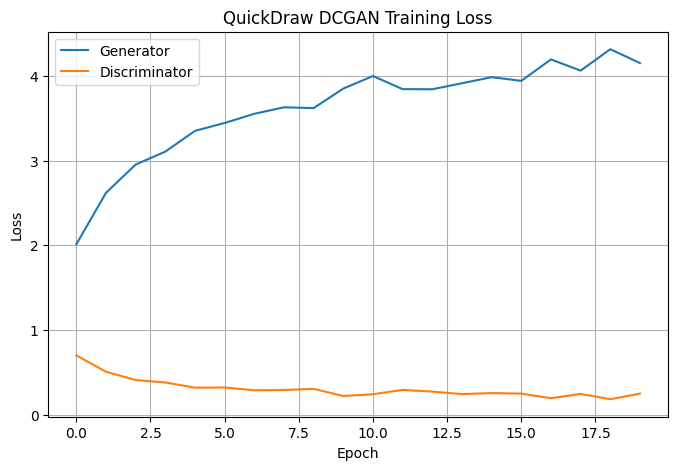

In [76]:
plt.figure(figsize=(8,5))

plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("QuickDraw DCGAN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

## 2.3.8 Generate Birthday Cake Sketches

After training, the Generator is used to create synthetic birthday cake sketches from randomly sampled latent vectors.

In [77]:
generator.eval()

with torch.no_grad():

    noise = torch.randn(25, latent_dim, 1, 1, device=device)

    fake_images = generator(noise).cpu()

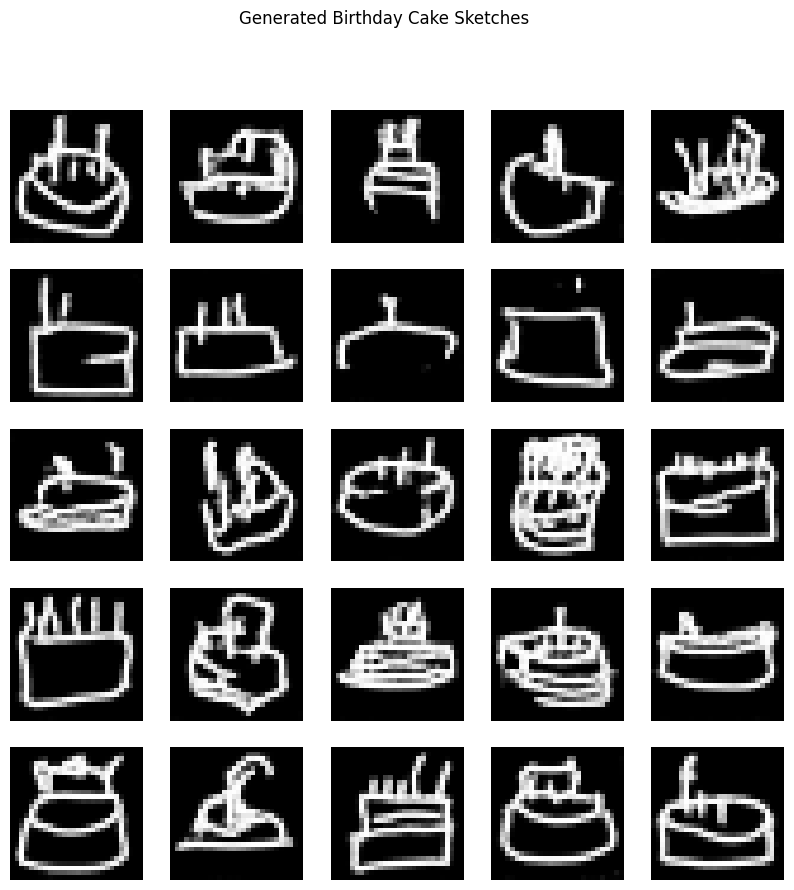

In [78]:
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(fake_images[i,0], cmap="gray")

    plt.axis("off")

plt.suptitle("Generated Birthday Cake Sketches")

plt.show()

## 2.3.9 Compare Real and Generated Sketches

Real birthday cake sketches are compared visually with the generated sketches to assess how well the DCGAN has learned the underlying drawing patterns.

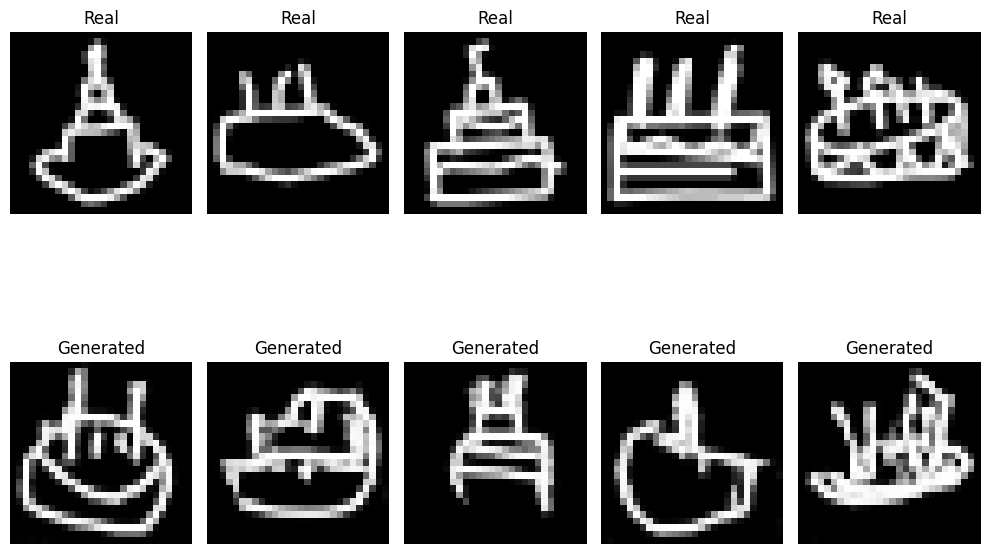

In [79]:
plt.figure(figsize=(10,8))

# Real Images
for i in range(5):

    plt.subplot(2,5,i+1)

    plt.imshow(cakes_tensor[i,0], cmap="gray")

    plt.title("Real")

    plt.axis("off")

# Fake Images
for i in range(5):

    plt.subplot(2,5,i+6)

    plt.imshow(fake_images[i,0], cmap="gray")

    plt.title("Generated")

    plt.axis("off")

plt.tight_layout()

plt.show()

## 2.3.10 Quantitative Evaluation using Frechet Inception Distance (FID)

The Frechet Inception Distance (FID) is calculated to quantitatively compare the generated birthday cake sketches with the real sketches. Lower FID values indicate that the generated images are statistically closer to the real image distribution.

In [80]:
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=64).to(device)

generator.eval()

batch_size = 100

with torch.no_grad():

    for i in range(0, 1000, batch_size):

        # Real images
        real = cakes_tensor[i:i+batch_size].to(device)

        # Fake images
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake = generator(noise)

        # Convert grayscale to RGB
        real = real.repeat(1,3,1,1)
        fake = fake.repeat(1,3,1,1)

        # Convert to uint8
        real = ((real + 1) * 127.5).clamp(0,255).to(torch.uint8)
        fake = ((fake + 1) * 127.5).clamp(0,255).to(torch.uint8)

        fid.update(real, real=True)
        fid.update(fake, real=False)

score = fid.compute()

print("FID Score:", float(score))

FID Score: 0.007559069432318211


## 2.3.11 Discussion

The generated birthday cake sketches capture the overall structure and appearance of the original QuickDraw drawings. Most generated samples contain recognizable cake-like shapes, although some images remain blurry or incomplete due to the limited training duration and the inherent difficulty of adversarial learning.

The visual comparison and FID score indicate that the DCGAN has learned important characteristics of the training distribution. However, additional training epochs, hyperparameter tuning, or more advanced GAN architectures could further improve image quality and diversity.

This experiment demonstrates how GANs can be applied in creative AI to generate novel sketches and artwork. The same adversarial learning framework can also be adapted to other drawing categories such as cats, houses, or ducks by training on the corresponding QuickDraw datasets.